# Credit Risk Prediction Model

The goal of this project is to build a Machine Learning model that predicts whether a person applying for a loan will default (fail to pay back the loan) or not default.

We first import the basic libraries we will work with. Numpy, for numerical computation; pandas, for data manipulation; matplotlib and seaborn for plotting.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Settings
pd.set_option('display.max_columns', None)
%matplotlib inline
print("Libraries imported successfully!")

Libraries imported successfully!


We import and inspect the dataset. It was obtained trough the Kaggle comunity, and it contains columns simulating credit bureau data.

| Feature Name | Description |
|-----------|-----------|
| person_age	| Age
| person_income	| Annual Income
| person_home_ownership	| Home ownership
| person_emp_length |	Employment length (in years)
| loan_intent |	Loan intent
| loan_grade |	Loan grade
| loan_amnt |	Loan amount
| loan_int_rate	| Interest rate
| loan_status	| Loan status (0 is non default 1 is default)
| loan_percent_income	| Percent income
| cb_person_default_on_file	| Historical default
| cb_person_cred_hist_length |	Credit history length

In [4]:
df = pd.read_csv('credit_risk_dataset.csv')

# Inspect dimensions and first 5 rows
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())

Dataset Shape: 32581 rows, 12 columns



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Our first task is cleaning the dataset by removing empty rows or unusual values that were added to the dataset by mistake. First, we check for missing values (NaN)

In [5]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

# Filter to show only columns with missing data
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
print("--- Missing Values Summary ---")
display(missing_summary)

--- Missing Values Summary ---


,Missing Count,Missing Percentage (%)
person_emp_length,895,2.747000
loan_int_rate,3116,9.563856


We are now dropping the NaN values. Since we are only removing around 10% of the data (out of 32500 rows), dropping the values will yield a cleaner (and still big enough) dataset. One idea could be to infer the loan interest rate column using the loan grade column, but I will just eliminate it to avoid synthetic bias.

We will also check for extreme outliers, unrealistic values.

In [6]:
df_clean = df.dropna().copy()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
print(f"Rows removed:   {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df):.2%})\n")

# Check for unrealistic numerical anomalies (for example age > 100, employment > 60 years)
display(df_clean[['person_age', 'person_emp_length', 'person_income', 'loan_amnt']].describe())

Original shape: (32581, 12)
Cleaned shape:  (28638, 12)
Rows removed:   3943 (12.10%)



,person_age,person_emp_length,person_income,loan_amnt
count,28638.000000,28638.000000,2.863800e+04,28638.000000
mean,27.727216,4.788672,6.664937e+04,9656.493121
std,6.310441,4.154627,6.235645e+04,6329.683361
min,20.000000,0.000000,4.000000e+03,500.000000
25%,23.000000,2.000000,3.948000e+04,5000.000000
50%,26.000000,4.000000,5.595600e+04,8000.000000
75%,30.000000,7.000000,8.000000e+04,12500.000000
max,144.000000,123.000000,6.000000e+06,35000.000000


We found unusual data in both the age and employment length column: no one can be 144 y.o. and no one can work for 123 years. We also found someone whose income is quite high: 6 million. We will treat it as feasible though. Therefore, we will only remove ages over 100 and employment lengths over 60 years.

In [7]:
df_clean = df_clean.drop(df_clean[df_clean.person_age > 100].index)
df_clean = df_clean.drop(df_clean[df_clean.person_emp_length > 60].index)

# df_clean = df_clean[df_clean['person_age'] <= 100]
# df_clean = df_clean[df_clean['person_emp_length'] <= 60]

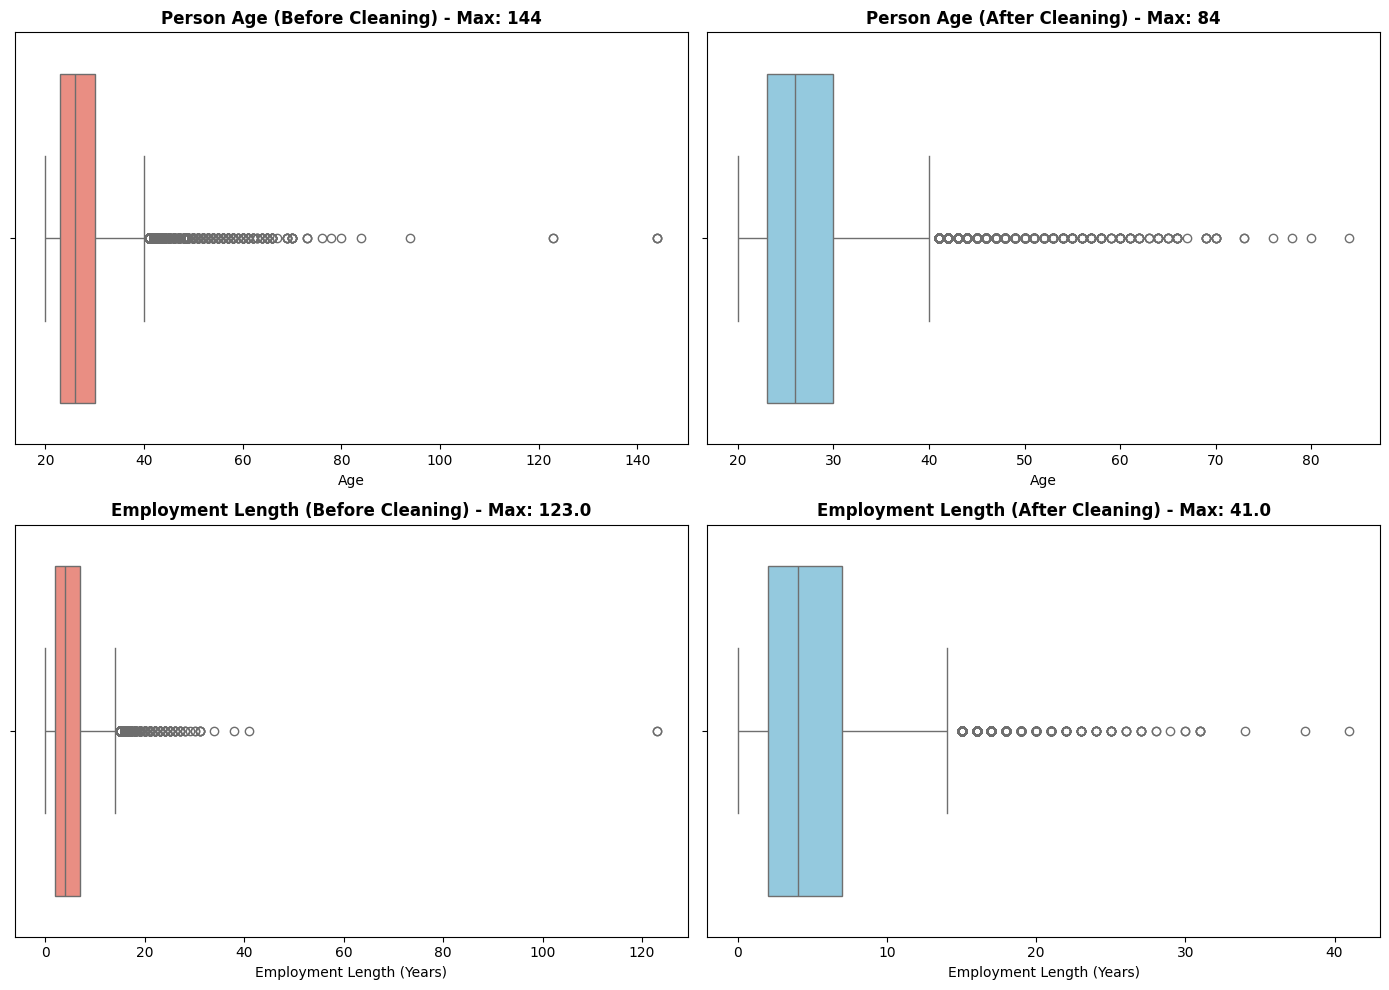

In [8]:
# Cell: Boxplot Comparison Before and After Cleaning
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Person Age - BEFORE Cleaning
sns.boxplot(data=df, x='person_age', ax=axes[0, 0], color='salmon')
axes[0, 0].set_title(f"Person Age (Before Cleaning) - Max: {df['person_age'].max()}", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')

# 2. Person Age - AFTER Cleaning
sns.boxplot(data=df_clean, x='person_age', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title(f"Person Age (After Cleaning) - Max: {df_clean['person_age'].max()}", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')

# 3. Employment Length - BEFORE Cleaning
sns.boxplot(data=df, x='person_emp_length', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title(f"Employment Length (Before Cleaning) - Max: {df['person_emp_length'].max()}", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Employment Length (Years)')

# 4. Employment Length - AFTER Cleaning
sns.boxplot(data=df_clean, x='person_emp_length', ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title(f"Employment Length (After Cleaning) - Max: {df_clean['person_emp_length'].max()}", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Employment Length (Years)')

plt.tight_layout()
plt.show()

Now we will encode the features, to turn categorical features into something easier to work with; and rescale them, so that big numeric values like salary don't dominate over smaller values like age (A salary increase of 100€ is not much compared to being 100 years older).

First off, we select the categorical columns,


*   person_home_ownership: ['RENT', 'MORTGAGE', 'OWN', 'OTHER']

*   loan_intent: ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']

*   loan_grade: ['A', 'B', 'C', 'D', 'E', 'F', 'G']

*   cb_person_default_on_file: ['Y', 'N'],

and then we use for ordinal categories the label encoder from skicit to do transform the labels into numbers from 0 to the numbers of classes - 1. For nominal features we will use one-hot encoding (1 or 0, yes or no).

In [9]:
df_encoded = df_clean.copy()

# Ordinal Mapping for Ranked Risk Features
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
default_file_map = {'N': 0, 'Y': 1}

df_encoded['loan_grade'] = df_encoded['loan_grade'].map(grade_map)
df_encoded['cb_person_default_on_file'] = df_encoded['cb_person_default_on_file'].map(default_file_map)

# One-Hot Encoding for Nominal Categorical Features
nominal_cols = ['person_home_ownership', 'loan_intent']

df_encoded = pd.get_dummies(
    df_encoded,
    columns=nominal_cols,
    drop_first=True,  # to avoid linear dependence (variables are inferred from the value of other variables)
    dtype=int
)

print(f"Dataset shape after encoding: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns\n")
print("New columns created via One-Hot Encoding:")
print([col for col in df_encoded.columns if 'person_home' in col or 'loan_intent' in col])

print("\nEncoded DataFrame preview:")
df_encoded.head()

Dataset shape after encoding: 28632 rows, 18 columns

New columns created via One-Hot Encoding:
['person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']

Encoded DataFrame preview:


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,21,9600,5.0,1,1000,11.14,0,0.10,0,2,0,1,0,1,0,0,0,0
2,25,9600,1.0,2,5500,12.87,1,0.57,0,3,0,0,0,0,0,1,0,0
3,23,65500,4.0,2,35000,15.23,1,0.53,0,2,0,0,1,0,0,1,0,0
4,24,54400,8.0,2,35000,14.27,1,0.55,1,4,0,0,1,0,0,1,0,0
5,21,9900,2.0,0,2500,7.14,1,0.25,0,2,0,1,0,0,0,0,0,1


Les's inspect our data set. What is the proportion between defaults and people who pay back their loans?

--- Class Imbalance Breakdown ---
Non-Default (0): 22,430 loans (78.34%)
Default     (1): 6,202 loans (21.66%)



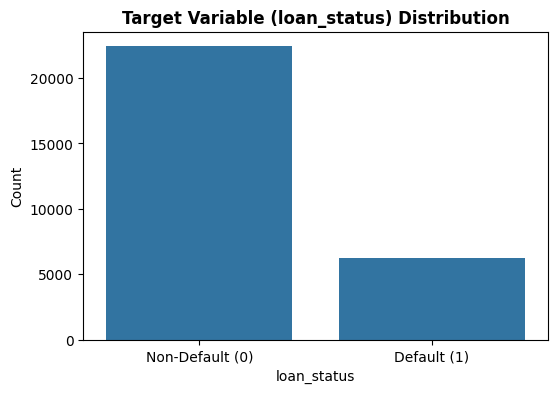

In [10]:
# Cell 7: Separate Features (X) and Target (y) & Check Class Imbalance
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']

# Check class distribution
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print("--- Class Imbalance Breakdown ---")
print(f"Non-Default (0): {class_counts[0]:,} loans ({class_percentages[0]:.2f}%)")
print(f"Default     (1): {class_counts[1]:,} loans ({class_percentages[1]:.2f}%)\n")

# Visualizing Imbalance
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(ticks=[0, 1], labels=['Non-Default (0)', 'Default (1)'])
plt.title('Target Variable (loan_status) Distribution', fontweight='bold')
plt.ylabel('Count')
plt.show()

We can see that the dataset is imbalanced. If we just tried to train a classifier based on accuracy, it could get a good accuracy by just predicting "nobody defaults"; around 78%. But in reality is missing 100% of the actual defaults, which is catastrophic. Therefore, we will not use accuracy as a metric, but rather ROC-AUC, which gives us information about the balance between true positives and false positives.

Now, we will split the dataset in 5 using K-Fold-Cross-Validation, to ensure that all the splits keep the class proportion balanced, since, with enough bad luck, we could be training the model on a set that barely contains defaults, just because we got an unlucky split.

It is also now when we will do the scaling. It is really important to scale the dataset **after** separating into training and test set, otherwise the mean and standard deviation used in the scaling could give out information about the whole set (data leakage). In order to prevent this, the test set will be rescaled using the same rule used in the training set.

Lastly, the models that we will train are K-Nearest Neighbours, Logistic Regression, and XGBoost

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

# Dictionary to store out-of-fold predictions and probabilities for ROC plotting
cv_results = {model_name: {'auc_scores': [], 'y_true': [], 'y_probs': []} for model_name in models}

print("--- Starting 5-Fold Stratified Cross-Validation ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Scale numerical features strictly within each fold (prevents data leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    print(f"\nEvaluating Fold {fold}/5...")

    for name, model in models.items():
        # XGBoost works natively with unscaled tree splits; KNN & Logistic Reg need scaled inputs
        if name == 'XGBoost':
            model.fit(X_train, y_train)
            probs = model.predict_proba(X_val)[:, 1]
        else:
            model.fit(X_train_scaled, y_train)
            probs = model.predict_proba(X_val_scaled)[:, 1]

        # Calculate ROC-AUC for this fold
        auc = roc_auc_score(y_val, probs)
        cv_results[name]['auc_scores'].append(auc)
        cv_results[name]['y_true'].extend(y_val)
        cv_results[name]['y_probs'].extend(probs)

        print(f"  > {name:20s} ROC-AUC: {auc:.4f}")

# Summary Table
print("\n" + "="*45)
print("     FINAL 5-FOLD MEAN ROC-AUC SCORES")
print("="*45)
for name in models:
    mean_auc = np.mean(cv_results[name]['auc_scores'])
    std_auc = np.std(cv_results[name]['auc_scores'])
    print(f"{name:22s}: {mean_auc:.4f} (+/- {std_auc:.4f})")


--- Starting 5-Fold Stratified Cross-Validation ---

Evaluating Fold 1/5...
  > K-Nearest Neighbors  ROC-AUC: 0.8764
  > Logistic Regression  ROC-AUC: 0.8675


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:52:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  > XGBoost              ROC-AUC: 0.9535

Evaluating Fold 2/5...
  > K-Nearest Neighbors  ROC-AUC: 0.8809
  > Logistic Regression  ROC-AUC: 0.8690


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:53:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  > XGBoost              ROC-AUC: 0.9499

Evaluating Fold 3/5...
  > K-Nearest Neighbors  ROC-AUC: 0.8565
  > Logistic Regression  ROC-AUC: 0.8631


...

  > XGBoost              ROC-AUC: 0.9480

Evaluating Fold 4/5...
  > K-Nearest Neighbors  ROC-AUC: 0.8623
  > Logistic Regression  ROC-AUC: 0.8620


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:53:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  > XGBoost              ROC-AUC: 0.9478

Evaluating Fold 5/5...
  > K-Nearest Neighbors  ROC-AUC: 0.8671
  > Logistic Regression  ROC-AUC: 0.8669


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:53:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  > XGBoost              ROC-AUC: 0.9487

     FINAL 5-FOLD MEAN ROC-AUC SCORES
K-Nearest Neighbors   : 0.8686 (+/- 0.0089)
Logistic Regression   : 0.8657 (+/- 0.0027)
XGBoost               : 0.9496 (+/- 0.0021)


Let's plot the ROC curves to check the precision of the different models.

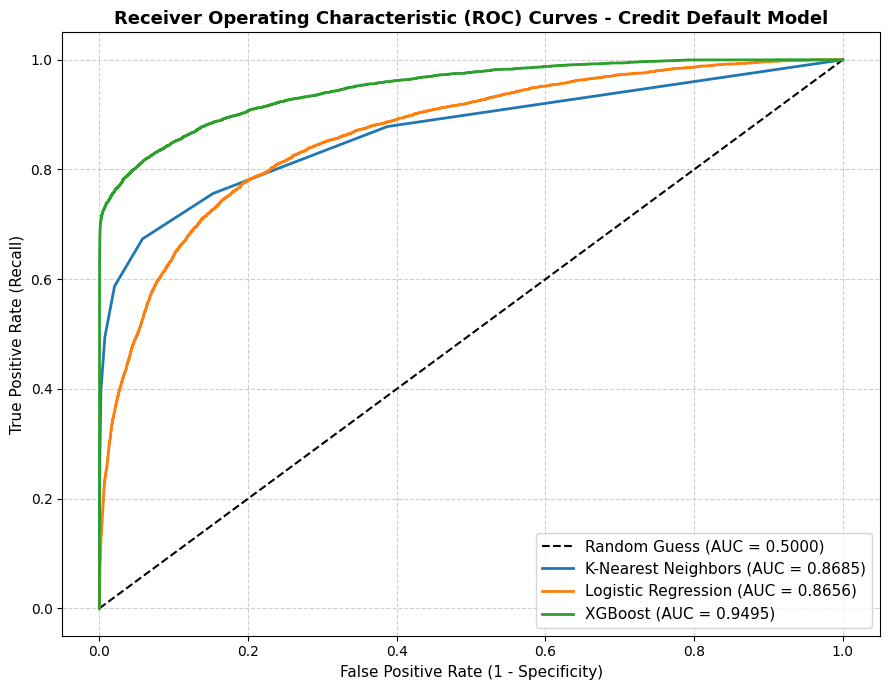

In [15]:
plt.figure(figsize=(9, 7))

# Plot random guess baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)')

for name in models:
    y_true = cv_results[name]['y_true']
    y_probs = cv_results[name]['y_probs']

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    overall_auc = roc_auc_score(y_true, y_probs)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {overall_auc:.4f})')

plt.title('Receiver Operating Characteristic (ROC) Curves - Credit Default Model', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

Better results were achieved with XGBoost: decision trees are better ar capturing non linear feature interactions like the loan grade and loan percent income.

We now study the XGB model and try to understand it deeply: let's perform a Feature Importance Inspection, which quantifies how much each feature contributed to reducing uncertainty (impurity) across all decision trees.

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:16:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


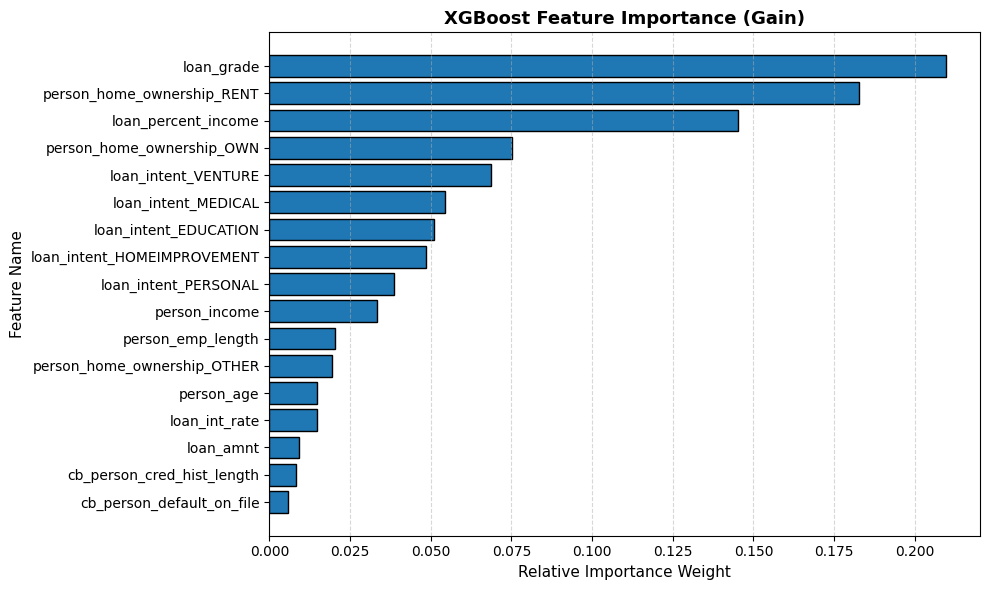

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Fit a standalone XGBoost model on the entire dataset to inspect global feature importance
xgb_full = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_full.fit(X, y)

# Extract feature importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_full.feature_importances_
}).sort_values(by='Importance', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#1f77b4', edgecolor='black')
plt.title('XGBoost Feature Importance (Gain)', fontsize=13, fontweight='bold')
plt.xlabel('Relative Importance Weight', fontsize=11)
plt.ylabel('Feature Name', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

We see that the top 3 features dominate the classification:
Loan grade condenses the historical credit worthiness, but also, lower grades obtain a higher interest rate, making the monthly payment burden also higher, thus creating a loop that increases the default probability.

Not owning or having a mortgage usually means a lack of asset backing: renters do not have property equity to rely on in times of crisis.

Lastly, a high loan percent income implies no safety margin and a high financial leverage, which makes default much more likely, since a minor unexpected expense or a slight salary reduction would leave the borrower with no way to service their debt.

Let's train a final XGB mdoel and perform a report that summarizes the performance obtained by the model when working with "real" data (our test-set).
We plot a confusion matrix that encodes the accuracy, precision (ratio of succesful positive predictions) and recall (ability to detect positives correctly)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# Lock away 20% Holdout Test Set BEFORE any scaling or CV
X_train_cv, X_holdout, y_train_cv, y_holdout = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Train/CV set size : {X_train_cv.shape[0]} samples")
print(f"Holdout Test set size: {X_holdout.shape[0]} samples (Default rate: {y_holdout.mean():.1%})")

# 5-Fold Stratified CV on the 80% split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in skf.split(X_train_cv, y_train_cv):
    X_tr, X_val = X_train_cv.iloc[train_idx], X_train_cv.iloc[val_idx]
    y_tr, y_val = y_train_cv.iloc[train_idx], y_train_cv.iloc[val_idx]

    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_tr, y_tr)

    probs = model.predict_proba(X_val)[:, 1]
    cv_scores.append(roc_auc_score(y_val, probs))

print(f"\n5-Fold CV Mean ROC-AUC: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

# Train final model on entire 80% train/CV set and evaluate on locked 20% Holdout
final_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
final_model.fit(X_train_cv, y_train_cv)

holdout_probs = final_model.predict_proba(X_holdout)[:, 1]
holdout_auc = roc_auc_score(y_holdout, holdout_probs)

print(f"FINAL HOLDOUT TEST ROC-AUC: {holdout_auc:.4f}")

Train/CV set size : 22905 samples
Holdout Test set size: 5727 samples (Default rate: 21.7%)


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:52:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:52:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:52:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:52:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:


5-Fold CV Mean ROC-AUC: 0.9456 (+/- 0.0042)


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:52:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


FINAL HOLDOUT TEST ROC-AUC: 0.9500


 CLASSIFICATION REPORT (Holdout Test Set @ Threshold = 0.25)
                 precision    recall  f1-score   support

Non-Default (0)       0.95      0.95      0.95      4486
    Default (1)       0.80      0.82      0.81      1241

       accuracy                           0.92      5727
      macro avg       0.88      0.88      0.88      5727
   weighted avg       0.92      0.92      0.92      5727



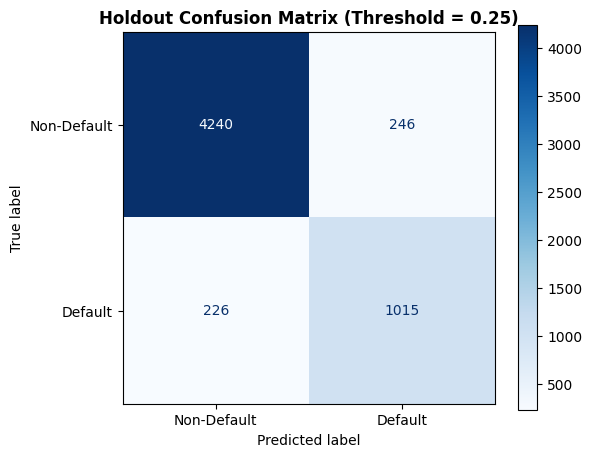

In [20]:
# Using optimal probability threshold based on base default rate (~0.21)
threshold = 0.25
y_pred_threshold = (holdout_probs >= threshold).astype(int)

print("="*60)
print(f" CLASSIFICATION REPORT (Holdout Test Set @ Threshold = {threshold})")
print("="*60)
print(classification_report(y_holdout, y_pred_threshold, target_names=['Non-Default (0)', 'Default (1)']))

# Display Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_holdout, y_pred_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Holdout Confusion Matrix (Threshold = {threshold})', fontsize=12, fontweight='bold')
plt.show()

### Conclusions

This project developed an end-to-end machine learning pipeline to evaluate consumer credit default risk using borrower demographic, financial, and credit bureau data.

Evaluating the final XGBoost model on the untouched 20% holdout test set (5,727 unseen loan applications) at an optimized probability threshold of 0.25 yielded the following results:   
 - Overall Accuracy: 92% across all test cases.   
 - Default Catch Rate (Recall): 82% (1,015 out of 1,241 actual defaults successfully flagged).   
 - Precision on Defaults: 80% (1,015 out of 1,261 predicted defaults were true defaults).   
 - F1-Score (Minority Class): 0.81, reflecting a strong balance between risk detection and minimizing unnecessary loan rejections

In retail banking, the cost of a False Negative (losing the entire principal on a defaulted loan) outweighs the opportunity cost of a False Positive (rejecting a creditworthy borrower).

By lowering the decision threshold from the default 0.50 down to 0.25, the model captured 82% of all potential non-performing loans while keeping unnecessary rejections low. This framework provides a transparent, scalable, and mathematically tool for automated loan underwriting, risk-based pricing, and capital allocation.